In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

# Part I - Logistic Regression for Binary Classification

## Exercise 1 - Load the dataset

* Load the diabetes dataset (`diabetes.csv`)
* Make a 70/30% train test partition of the dataset

*Suggestion:* I suggest you load it with pandas, but make a scikit-learn style dataset ($X$, $y$ numpy arrays)

In [3]:
# your code goes here:
diabetes_df = pd.read_csv('../data/diabetes.csv')
diabetes_X = diabetes_df.drop(columns=['Outcome']).values
diabetes_y = diabetes_df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(diabetes_X, diabetes_y, train_size=0.7)

In [4]:
x_train_avg = X_train.mean()
x_train_std = X_train.std()

X_train = (X_train - x_train_avg) / x_train_std
X_test = (X_test - x_train_avg) / x_train_std

## Excercise 2 - Implementing Logistic Regression

* In this exercise you will implement the logistic regression algorithm to learn the vector of weights $\vec{w}$.
* You will then plot the ROC curve, and calculate the AUROC (Area Under the ROC curve) using `sklearn.metrics.roc_auc_score()` for the testing set.

You can follow the structure for gradient descent as described in the previous labs and slides. Don't forget to write a function that calculates the sigmoid. You are not allowed in this exercise to use any existing functions.
* **Note that:** in the book and slides `y` is written as `t` and `y_hat` as `y`. 

Remember that $\nabla E(w) = \sum_{n=1}^N (y_n - t_n)\phi_n$ 

* _Tip:_ plot the loss during training to verify that everything is working properly.

In [5]:
# your code goes here:
# implement logistic regression using numpy following: $\nabla E(w) = \sum_{n=1}^N (y_n - t_n)\phi_n$ 

def get_loss(y_true, y_predict):
    erro = 1e-12
    pos = y_true * np.log(y_predict + erro)
    neg = (1-y_true) * np.log(1 - y_predict + erro)
    return -(pos+neg).mean()

def sigmoid(a):
    return 1/(1+np.exp(-a))

def log_reg(X, y, max_iter=100, lr=1e-2):
    n_datapoints = X.shape[0]
    ones = np.ones(n_datapoints)
    phi = np.column_stack((ones, X))
    w = np.random.normal(0, 1, phi.shape[1]) * 1e-1
    loss_hist = []

    for _ in range(max_iter):
        y_pred = sigmoid(phi @ w)
        grad = phi.T @ (y_pred - y) / n_datapoints
        w -= lr * grad

        loss_hist.append(get_loss(y, y_pred))

    return w, loss_hist


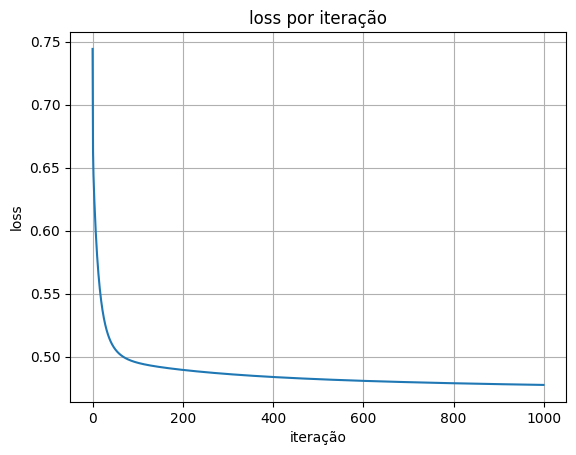

In [6]:
w, loss_hist = log_reg(X_train, y_train, max_iter=1000, lr=1)

sns.lineplot(loss_hist)
plt.ylabel("loss")
plt.xlabel("iteração")
plt.title("loss por iteração")
plt.grid(True)

Evaluate the performance of your model, plot the ROC curve and calculate the AUROC

In [7]:
from sklearn.metrics import roc_auc_score

AUROC:  0.8287890938251805


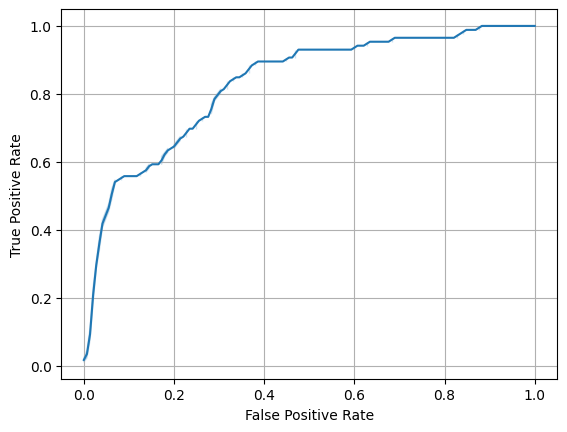

In [8]:
# your code goes here: 

def get_conf_mtrx(y_true, y_predict):
    conf_mtrx = [[0, 0],[0, 0]]
    conf_mtrx[0][0] = ((y_true == 1) & (y_predict == 1)).astype(int).sum() # true positive
    conf_mtrx[0][1] = ((y_true == 0) & (y_predict == 1)).astype(int).sum() # false positive
    conf_mtrx[1][0] = ((y_true == 1) & (y_predict == 0)).astype(int).sum() # false negative
    conf_mtrx[1][1] = ((y_true == 0) & (y_predict == 0)).astype(int).sum() # true negative

    return conf_mtrx

def get_ROC(y_true, y_proba, treshold=0.5):
    y_predict = (y_proba >= treshold).astype(int)

    conf_mtrx = get_conf_mtrx(y_true, y_predict)

    true_pos_rate = conf_mtrx[0][0] / (conf_mtrx[0][0] + conf_mtrx[1][0])
    false_pos_rate = conf_mtrx[0][1] / (conf_mtrx[0][1] + conf_mtrx[1][1])

    return true_pos_rate, false_pos_rate

phi_teste = np.column_stack((np.ones(X_test.shape[0]), X_test))
y_proba = sigmoid(phi_teste @ w)

auroc = roc_auc_score(y_test, y_proba)
print("AUROC: ", auroc)

roc = np.array([get_ROC(y_test, y_proba, p) for p in np.unique(y_proba)])

sns.lineplot(x=roc[:,1], y=roc[:,0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)

# Part IV - Logistic Regression for multi-class classification

## Exercise 1 - Load the dataset
* Load the famous Iris dataset (using sklearn as shown below)
* Load the data in a matrix $X$ and the target in a vector $y$.
* Make a 70/30% train test partition of the dataset

In [9]:
from sklearn.datasets import load_iris

In [10]:
iris = load_iris()

Prepare $X$ and $y$

In [11]:
# your code goes here:
X_iris = iris.data
y_iris = iris.target

print("features: ", iris.feature_names)
print("classes: ", iris.target_names)
print("classes values: ", np.unique(iris.target))

features:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
classes:  ['setosa' 'versicolor' 'virginica']
classes values:  [0 1 2]


Split the data

In [12]:
# your code goes here:

Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_iris, y_iris, train_size=0.7)

print("train size: ", Xi_train.shape[0])
print("test size: ", Xi_test.shape[0])

train size:  105
test size:  45


## Exercise 2 - Train the Logistic Regression model
Train your LogisticRegression multi-class classifier using the sklearn implementation. 
* To use the cross entropy loss function and softmax activation function, the `multi_class` parameter needs to be set to "multinomial"

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
# Let's create an instance of the LogisticRegression classifier for multiclass classification
lr_iris = LogisticRegression(solver='newton-cg')

Fit the data

In [15]:
# your code goes here: 
clf = lr_iris.fit(Xi_train, yi_train)

## Exercise 3 - Make predictions and evaluate the model
Use the `predict_proba()` method to obtain the output of the predictions for the testing set. The values are the output of the softmax activation function. 
* Remember that the highest value of each prediction corresponds to the actual predicted class.
* Write a function `get_predicted_class()` that transforms the vector of softmax outputs (obtained from `predict_proba()`) to a vector that just contains the predicted class. 
    - This function takes as input a matrix $\hat{Y}_{proba} \in \mathbb{R}^{m\times k}$ where $m$ is the number of samples in the testing set and $k$ is the number of classes.

As an example: if the softmax output is as follows: `Y_pred_sm = [[0.1,0.2,0.7], [0.4,0.3,0.3]]`, then `get_predicted_class(Y_pred_sm)` should return: `[2,0]` as the highest value for the 1st prediction is class 2 and for the 2nd prediction is class 0.

In [16]:
# complete the input argument for the function to obtain the predictions for the testing set.
def get_predicted_class(y_prob):
    return np.argmax(y_prob, axis=1)

y_pred_sm = lr_iris.predict_proba(Xi_test)
y_pred = get_predicted_class(y_pred_sm)

Now calculate the accuracy in the testing set using `y_pred`
- Try calculating the accuracy without using the sklearn function :)

accuracy:  0.9333333333333333


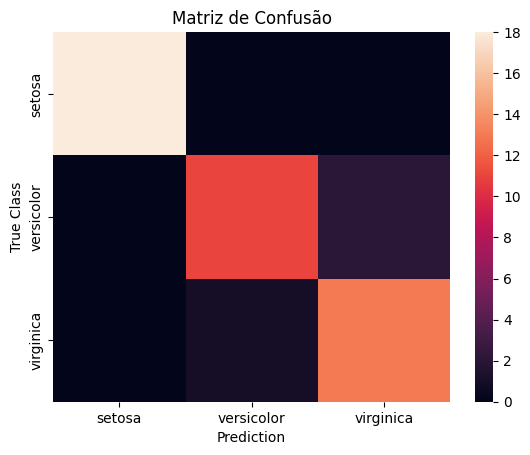

In [17]:
# your code goes here:

acc = (yi_test == y_pred).astype(int).mean()
print("accuracy: ", acc)

n = len(iris.target_names)
conf_mtrx = np.zeros((n,n))
for t, p in zip(yi_test, y_pred):
    conf_mtrx[t, p] += 1

sns.heatmap(conf_mtrx, xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Prediction")
plt.ylabel("True Class")
plt.title("Matriz de Confusão")
plt.show()